(253, 3)


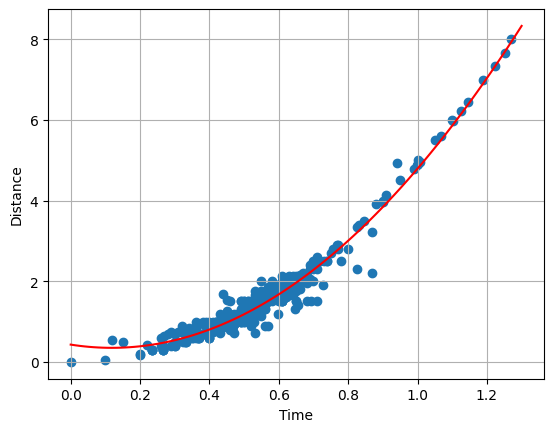

0.9655286788215308
[[ 0.         -1.35153854  5.71396783]]


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv("../data_sets/gravity_data.csv")
x = df["t"]
y = df["d"]
x = np.array(x).reshape(-1, 1)
y = np.array(y).reshape(-1, 1)

plt.scatter(x, y)
plt.grid(1)
plt.xlabel("Time")
plt.ylabel("Distance")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33)

poly_x = PolynomialFeatures(2)
t_train = poly_x.fit_transform(x_train)
print(t_train.shape)  # 3 columns: x^0, x^1, x^2
# Alternatively: t_train = x_train**2  # This only gives x^2

model = LinearRegression()
model.fit(t_train, y_train)

# Plotting
x_plot = np.linspace(0, 1.3, 100).reshape(-1, 1)
t_plot = poly_x.fit_transform(x_plot)
plt.plot(x_plot, model.predict(t_plot), 'r')
plt.show()

# Testing
t_test = poly_x.fit_transform(x_test)
print(model.score(t_test, y_test))
print(model.coef_)

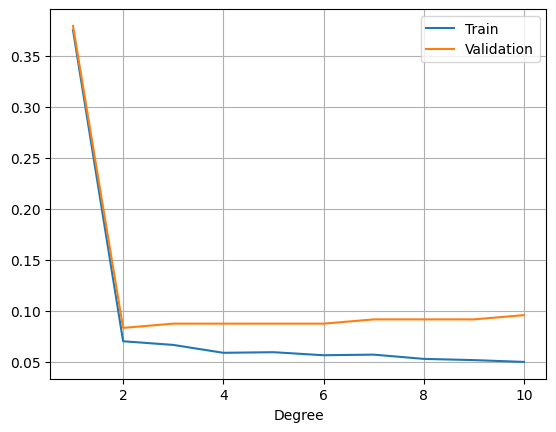

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate

df = pd.read_csv("../data_sets/quad.csv")
data = df.to_numpy()
x = data[:, 0:2]
y = data[:, 2]

x_train = x[0:240, :]
y_train = y[0:240]
x_test = x[240:, :]
y_test = y[240:]

model = LogisticRegression(max_iter = 500)

D = 10
validation_error = np.empty(D)
training_error = np.empty(D)
for i in range(D):
    d = i+1
    poly_x = PolynomialFeatures(d)
    t_train = poly_x.fit_transform(x_train)

    cv_results = cross_validate(model, t_train, y_train, cv = 8, return_train_score = True)
    training_error[i] = 1 - np.mean(cv_results["train_score"])
    validation_error[i] = 1 - np.mean(cv_results["test_score"])

plt.plot([i+1 for i in range(D)], training_error, label = "Train")
plt.plot([i+1 for i in range(D)], validation_error, label = "Validation")
plt.legend()
plt.grid(1)
plt.xlabel("Degree")
plt.show()
